# Проектная работа в стартапе

Цель: изучить поведение пользователей мобильного приложения для повышения качества взаимодействия пользователей с приложением

***План работ:***

**Шаг 1. Загрузка данных и изучение общей информации**\
Путь к файлу: /datasets/logs_exp.csv. Скачать датасет

**Шаг 2. Подготовка данных к анализу**
- Замена названий столбцов;
- Проверить пропуски и типы данных. Откорректировать, если нужно;
- Добавить столбец даты и времени, а также отдельный столбец дат;

**Шаг 3. Изучить и проверить данные**
- Сколько всего событий в логе?
- Сколько всего пользователей в логе?
- Сколько в среднем событий приходится на пользователя?
- Данными за какой период располагаете? Найти максимальную и минимальную дату. Изучить, как меняется количество данных: постройте столбчатую диаграмму, которая отобразит количество событий в зависимости от времени в разрезе групп. Можно ли быть уверенным, что у вас одинаково полные данные за весь период? Технически в логи новых дней по некоторым пользователям могут «доезжать» события из прошлого — это может «перекашивать данные». Определить, с какого момента данные полные и отбросить более старые. Данными за какой период времени располагаете на самом деле?
- Много ли событий и пользователей вы потеряли, отбросив старые данные?
- Проверить, что есть пользователи из всех трёх экспериментальных групп.

**Шаг 4. Изучить воронку событий**
- Посмотреть, какие события есть в логах, как часто они встречаются. Отсортировать события по частоте.
- Посчитать, сколько пользователей совершали каждое из этих событий. Отсортировать события по числу пользователей. Посчитать долю пользователей, которые хоть раз совершали событие.
- Предположить, в каком порядке происходят события. Все ли они выстраиваются в последовательную цепочку? Их не нужно учитывать при расчёте воронки.
- По воронке событий посчитать, какая доля пользователей проходит на следующий шаг воронки (от числа пользователей на предыдущем). То есть для последовательности событий A → B → C посчитать отношение числа пользователей с событием B к количеству пользователей с событием A, а также отношение числа пользователей с событием C к количеству пользователей с событием B.
- На каком шаге теряете больше всего пользователей?
- Какая доля пользователей доходит от первого события до оплаты?

**Шаг 5. Изучить результаты эксперимента**
- Сколько пользователей в каждой экспериментальной группе?
- Есть 2 контрольные группы для А/А-эксперимента, чтобы проверить корректность всех механизмов и расчётов. Проверить, находят ли статистические критерии разницу между выборками 246 и 247.
- Выбрать самое популярное событие. Посчитать число пользователей, совершивших это событие в каждой из контрольных групп. Посчитать долю пользователей, совершивших это событие. Проверить, будет ли отличие между группами статистически достоверным. Проделать то же самое для всех других событий (удобно обернуть проверку в отдельную функцию). Можно ли сказать, что разбиение на группы работает корректно?
- Аналогично поступить с группой с изменённым шрифтом. Сравнить результаты с каждой из контрольных групп в отдельности по каждому событию. Сравнить результаты с объединённой контрольной группой. Какие выводы из эксперимента можно сделать?
- Какой уровень значимости вы выбрали при проверке статистических гипотез выше? Посчитать, сколько проверок статистических гипотез вы сделали. При уровне значимости 0.1 в 10% случаев можно ошибочно отклонить нулевую гипотезу при условии, что она верна. Какой уровень значимости стоит применить? Если вы хотите изменить его, проделайте предыдущие пункты и проверьте свои выводы.

## Шаг 1. Загрузка данных и изучение общей информации

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import scipy.stats as stats
from scipy import stats as st
import math as mth
import numpy as np
from datetime import datetime, timedelta
import datetime as dt
import seaborn as sns

In [2]:
# отображение всех колонок при выводе на печать
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_csv('/datasets/logs_exp.csv', sep='\t')
data.info()
display(data.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
5,CartScreenAppear,6217807653094995999,1564055323,248
6,OffersScreenAppear,8351860793733343758,1564066242,246
7,MainScreenAppear,5682100281902512875,1564085677,246
8,MainScreenAppear,1850981295691852772,1564086702,247
9,MainScreenAppear,5407636962369102641,1564112112,246


EventName — название события;\
DeviceIDHash — уникальный идентификатор пользователя;\
EventTimestamp — время события - представлен в секундах;\
ExpId — номер эксперимента: 246 и 247 — контрольные группы, а 248 — экспериментальная.

***Итог:***
Датасет состоит из 4 столбцов. Пропуски на первый взгляд не обнаружены, более детально рассмотрим далее. Необходимо изменить названия столбов и привести их к правилам стиля. Столбец с временем события представлен в секундах. Типы данных менять не нужно.

## Шаг 2.  Подготовка данных к анализу

In [4]:
# преобразование имен всех столбцов 
data = data.rename(columns = {'EventName':'event_name', 'DeviceIDHash':'user_id', 'EventTimestamp':'event_time', \
                              'ExpId':'exp_id'})
print(list(data.columns.values))

['event_name', 'user_id', 'event_time', 'exp_id']


In [5]:
display(data.isna().sum()) # количество пропущенных значений для каждого столбца 
dup=data.duplicated().sum() # число дубликатов 
dup

event_name    0
user_id       0
event_time    0
exp_id        0
dtype: int64

413

In [6]:
dup_ratio = dup/len(data)
print('Процент дубликатов во всем датасете {:.1%}'.format(dup_ratio))

Процент дубликатов во всем датасете 0.2%


Процент дубликатов мал, поэтому можно смело удалить их.

In [7]:
data=data.drop_duplicates()# удаление дубликатов

In [8]:
data['datetime'] = pd.to_datetime(data['event_time'], unit='s')# добавляем столбец даты и времени типа datetime64
data['date']=data['datetime'].dt.floor('d') # добавляем столбец дат

In [9]:
data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 243713 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event_name  243713 non-null  object        
 1   user_id     243713 non-null  int64         
 2   event_time  243713 non-null  int64         
 3   exp_id      243713 non-null  int64         
 4   datetime    243713 non-null  datetime64[ns]
 5   date        243713 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(3), object(1)
memory usage: 13.0+ MB


,event_name,user_id,event_time,exp_id,datetime,date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


In [10]:
data['date'].sort_values().unique()

array(['2019-07-25T00:00:00.000000000', '2019-07-26T00:00:00.000000000',
       '2019-07-27T00:00:00.000000000', '2019-07-28T00:00:00.000000000',
       '2019-07-29T00:00:00.000000000', '2019-07-30T00:00:00.000000000',
       '2019-07-31T00:00:00.000000000', '2019-08-01T00:00:00.000000000',
       '2019-08-02T00:00:00.000000000', '2019-08-03T00:00:00.000000000',
       '2019-08-04T00:00:00.000000000', '2019-08-05T00:00:00.000000000',
       '2019-08-06T00:00:00.000000000', '2019-08-07T00:00:00.000000000'],
      dtype='datetime64[ns]')

Данные предоставлены с 25 июля 2019 по 7 августа 2019 года.

In [11]:
data['exp_id'].value_counts()# частота встречаемости групп

248    85582
246    80181
247    77950
Name: exp_id, dtype: int64

In [12]:
# сколько пользователей попали одновременно в несколько группы
data.groupby('user_id').agg({'exp_id' : 'nunique'}).query('exp_id>1').count()

exp_id    0
dtype: int64

***Вывод:***

Корректно перобразовали названия столбов. Удалены дубликаты. Пропуски не обнаружены. Добавлен столбец даты и времени, а также отдельный столбец дат. Данные предоставлены с 25 июля 2019 по 7 августа 2019 года. Распределение пользователей по группам корректно. 

## Шаг 3. Изучить и проверить данные

### Сколько всего событий в логе:

In [13]:
print('Всего событий в логе', len(data['event_name']))

Всего событий в логе 243713


In [14]:
data['event_name'].value_counts()# частота встречаемости событий

MainScreenAppear           119101
OffersScreenAppear          46808
CartScreenAppear            42668
PaymentScreenSuccessful     34118
Tutorial                     1018
Name: event_name, dtype: int64

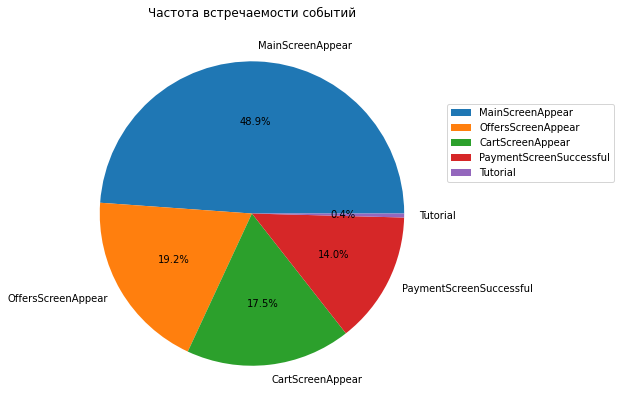

In [15]:
data.groupby('event_name').agg({'user_id':'count'}).sort_values(by='user_id', ascending=False)\
    .plot(kind='pie', y='user_id', autopct='%1.1f%%', figsize=(7,7), label='', title='Частота встречаемости событий')
plt.legend(bbox_to_anchor=(1, 0.8)); # расположение легенды на графике

***Итог:***

Всего событий в логе 243713. Состоят из 5 видов событий:\
MainScreenAppear - Просмотр главной страницы приложения \
OffersScreenAppear - Перешёл на страницу предложений \
CartScreenAppear - Перешёл на страницу «Корзина» \
PaymentScreenSuccessful - Перешёл на страницу «Успешный заказ»\
Tutorial - Перешёл на страницу часто задаваемых вопросов

Больше всего обращений к главной странице приложения - 49% вызова этого события пользователями. Событие успешного заказа составляет лишь 14% вызовов. К странице часто задаваемых вопросов вообще практически не обращаются - меньше 0.4%. Практически одинаково, по 17-19%, осуществляется вывод на экран страницы корзины и страницы предложений, что говорит о том, что примерно 2% пользователей, которые просматривают предложения не добавляют ничего в корзину.

### Сколько всего пользователей в логе:

In [16]:
data['user_id'].nunique()# кол-во уникальных user_id

7551

In [17]:
# число пользователей по группам
count_user=data.groupby('exp_id').agg({'user_id':'nunique'}).reset_index().sort_values(by='user_id', ascending=False)
count_user.columns = ['exp_id','count_user']
count_user

,exp_id,count_user
2,248,2542
1,247,2520
0,246,2489


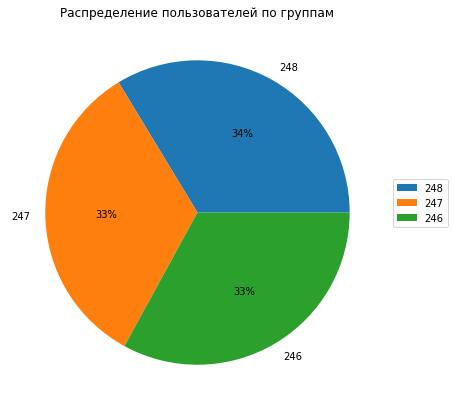

In [18]:
data.groupby('exp_id').agg({'user_id':'nunique'}).sort_values(by='user_id', ascending=False)\
    .plot(kind='pie', y='user_id', autopct='%1.0f%%', figsize=(7,7), label='')
plt.legend(bbox_to_anchor=(1, 0.6)); # расположение легенды на графике
plt.title('Распределение пользователей по группам');

***Итог:***

Всего уникальных пользователей в логе 7551, из них:\
В 248 группе: 2542 человек \
В 247 группе: 2520 человек \
В 246 группе: 2489 человек 

Две контрольные группы со старыми шрифтами 246 и 247 одинаковы в процентном соотношении - по 33%. Экспериментальная группа составляет 34% пользователей.

### Сколько в среднем событий приходится на пользователя:

In [19]:
# число событий по пользователям
count_event_user=data.groupby('user_id').agg({'event_name':'count'}).reset_index()
count_event_user.columns = ['user_id','count_event']
print('В среднем на пользователя приходится', round(count_event_user['count_event'].mean()), 'события')

В среднем на пользователя приходится 32 события


In [20]:
count_event_user['count_event'].describe().round(1)

count    7551.0
mean       32.3
std        65.2
min         1.0
25%         9.0
50%        20.0
75%        37.0
max      2307.0
Name: count_event, dtype: float64

Медиана и среднее отличаются, следовательно, есть выбросы.

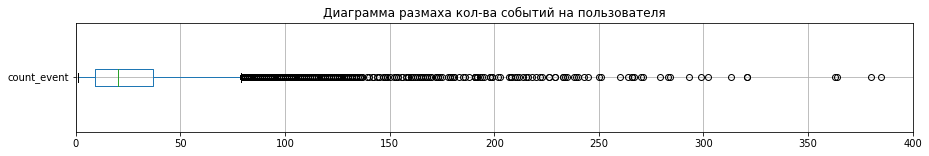

In [21]:
fig, ax = plt.subplots(figsize = (15,2))
ax = count_event_user[['count_event']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха кол-ва событий на пользователя')
ax.set_xlim(0, 400);

Диаграмма размаха показывает, что более 200 событий на пользователя встречаются редко.

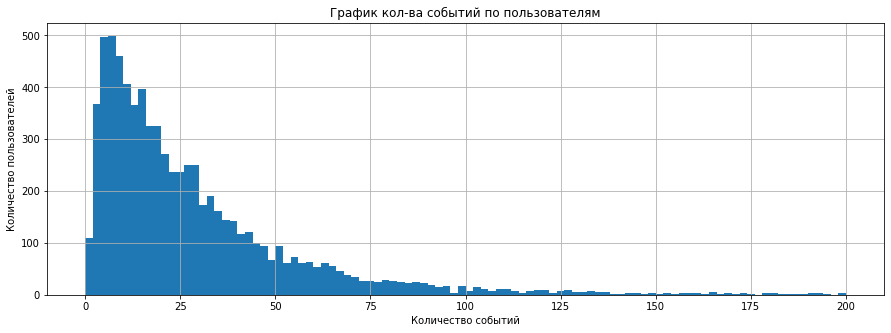

In [22]:
count_event_user['count_event'].plot(kind='hist', bins=100, grid=True, figsize = (15, 5), range=(0,200))
plt.ylabel('Количество пользователей')
plt.xlabel('Количество событий')
plt.title('График кол-ва событий по пользователям');

In [23]:
print('95 и 99 перцентили стоимости заказов:', np.percentile(count_event_user['count_event'], [95,99])) 

95 и 99 перцентили стоимости заказов: [ 89.  200.5]


Не более 1% данных, на которых приходится более 200 событий на пользователя. Все, что за 99 перцентилем будем считать аномалиями.

***Итог:***
В среднем на пользователя приходится 32 события. Были обнаружены аномальные значения - более 200 событий на пользователя. Но количество событий не повлияет на анализ, так как анализ конверсии и проверка гипотез выполняются по уникальным пользователям без учёта их активности.

### Данными за какой период располагаете? Найти максимальную и минимальную дату. Изучить, как меняется количество данных: постройте столбчатую диаграмму, которая отобразит количество событий в зависимости от времени в разрезе групп. Можно ли быть уверенным, что у вас одинаково полные данные за весь период? Технически в логи новых дней по некоторым пользователям могут «доезжать» события из прошлого — это может «перекашивать данные». Определить, с какого момента данные полные и отбросить более старые. Данными за какой период времени располагаете на самом деле?

In [24]:
print('Начальная дата', min(data['datetime']), 'и конечная дата', max(data['datetime']))

Начальная дата 2019-07-25 04:43:36 и конечная дата 2019-08-07 21:15:17


In [25]:
print('Данные предоставлены за', max(data['datetime']) - min(data['datetime']))

Данные предоставлены за 13 days 16:31:41


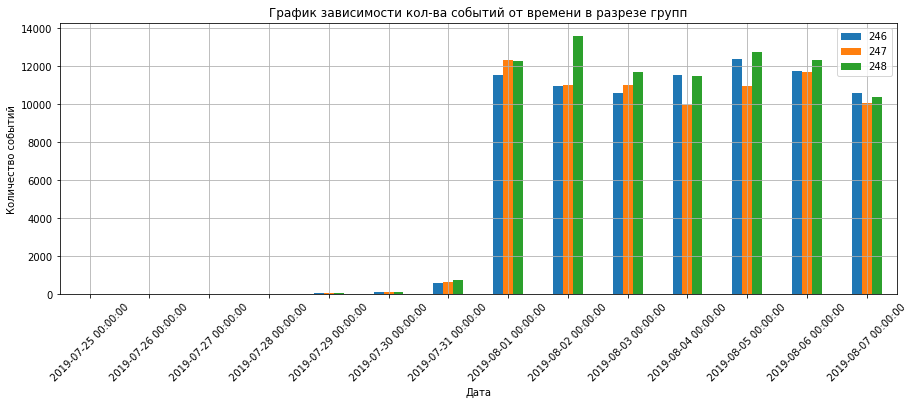

In [26]:
count_event_exp=data.pivot_table(index='date', columns='exp_id', values='event_name', aggfunc='count')\
    .sort_values(by='date').plot(kind='bar', grid=True, figsize=(15, 5))
plt.legend()
plt.xticks(rotation=45)
plt.ylabel('Количество событий')
plt.xlabel('Дата')
plt.title('График зависимости кол-ва событий от времени в разрезе групп');

В первые 7 дней количества событий в группах чрезвычайно низкие - будем считать их аномалиями. Это дни с неполными данными. Возможно, это связано со стартом работы приложения. Следовательно, с 1 августа 2019 года начинает накапливаться достаточное количество записей в логах для проведения событийного анализа.

In [27]:
clear_data=data.query('date >= "2019-08-01"')
print('По очищенным данным период составляет', max(clear_data['datetime']) - min(clear_data['datetime']))

По очищенным данным период составляет 6 days 21:07:49


In [28]:
print('Начальная дата', min(clear_data['datetime']), 'и конечная дата', max(clear_data['datetime']))

Начальная дата 2019-08-01 00:07:28 и конечная дата 2019-08-07 21:15:17


***Итого:***
После очистки данных от дней с неполными сведениями располагаем данными за 6 days 21:07:49 с 1 августа 2019 по 7 августа 2019 года.

### Много ли событий и пользователей вы потеряли, отбросив старые данные:

In [29]:
print('Количество событий по сырым данным', len(data))
print('Количество событий по очищенным данным', len(clear_data))
print('Процент очищенных данных {:.0%}'.format((len(data) - len(clear_data)) / len(data)))

Количество событий по сырым данным 243713
Количество событий по очищенным данным 240887
Процент очищенных данных 1%


In [30]:
user_cnt=data['user_id'].nunique()
print('Кол-во уникальных пользователей по сырым данным', user_cnt)

cl_user_cnt=clear_data['user_id'].nunique()
print('Кол-во уникальных пользователей по очищенным данным', cl_user_cnt)

print('Процент очищенных пользователей {:.0%}'.format((user_cnt - cl_user_cnt) / user_cnt))

Кол-во уникальных пользователей по сырым данным 7551
Кол-во уникальных пользователей по очищенным данным 7534
Процент очищенных пользователей 0%


In [31]:
print('В среднем на пользователя приходится', round(clear_data.groupby('user_id')\
                                    .agg({'event_name':'count'})['event_name'].mean()), 'событий по очищенным данным')


В среднем на пользователя приходится 32 событий по очищенным данным


***Итого:***
Процент очищенных данных составляет 1%, вследствие неполных данных о событиях за день. На очистку пользователей это не повлияло - процент очищенных пользователей составил 0%.

### Проверить, что есть пользователи из всех трёх экспериментальных групп

In [32]:
# число пользователей по группам без аномалий
clear_count_user=clear_data.groupby('exp_id').agg({'user_id':'nunique'}).reset_index()
clear_count_user

,exp_id,user_id
0,246,2484
1,247,2513
2,248,2537


***Итого:***

Всего уникальных пользователей в логе по очищенным данным 7534, из них:\
В 248 группе: 2537 человек \
В 247 группе: 2513 человек \
В 246 группе: 2484 человек


***Вывод:***

Всего в логе 5 видов событий: 
- просмотр главной страницы приложения - 49% обращений
- перешёл на страницу предложений - 19%
- перешёл на страницу «Корзина» - 17.5%
- перешёл на страницу «Успешный заказ» - 14% 
- перешёл на страницу часто задаваемых вопросов - 0.4%

Чаще всего обращаются к главной странице приложения. Важнейшее событие для бизнеса - это переход на страницу успешной оплаты, и тут всего 14% обращений к странице. Страницу часто задаваемых вопросов вызывают крайне редко. Практически одинаково осуществляется вывод на экран страницы корзины и страницы предложений, лишь небольшая разница между ними в 1.5% говорит о том, что данные пользователи не добавляют ничего в корзину.

По сырым данным:
- период предоставлен за 13 days 16:31:41 с 25 июля 2019 по 7 августа 2019;
- число пользователей в логе 7551. Распределение их по группам практически одинаково: две контрольные группы со старыми шрифтами 246 и 247 по 33% пользователей, а экспериментальная группа составляет 34%;
- количество событий 243713;
- в среднем на пользователя приходится 32 события.

После очистки данных:
- актуальный период за 6 days 21:07:49 с 1 августа 2019 по 7 августа 2019;
- число пользователей в логе 7534;
- количество событий 240887;
- в среднем на пользователя приходится 32 событий.

Тем самым убрали 1% данных.

## Изучить воронку событий

### Посмотреть, какие события есть в логах, как часто они встречаются. Отсортировать события по частоте.

In [33]:
clear_data['event_name'].value_counts()# частота встречаемости событий

MainScreenAppear           117328
OffersScreenAppear          46333
CartScreenAppear            42303
PaymentScreenSuccessful     33918
Tutorial                     1005
Name: event_name, dtype: int64

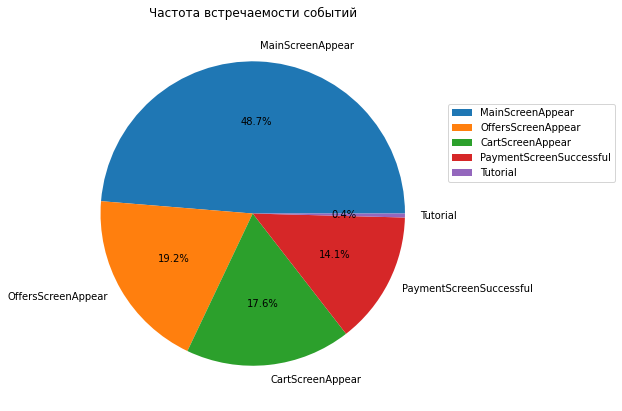

In [34]:
clear_data.groupby('event_name').agg({'user_id':'count'}).sort_values(by='user_id', ascending=False)\
    .plot(kind='pie', y='user_id', autopct='%1.1f%%', figsize=(7,7), label='', title='Частота встречаемости событий')
plt.legend(bbox_to_anchor=(1, 0.8)); # расположение легенды на графике

***Итого:***
После очистки данных показатели частоты вызова событий не изменились.

### Посчитать, сколько пользователей совершали каждое из этих событий. Отсортировать события по числу пользователей. Посчитать долю пользователей, которые хоть раз совершали событие.

In [35]:
# число пользователей по событиям по очищенным данным 
count_user_event=clear_data.groupby('event_name').agg({'user_id':'nunique'}).sort_values(by='user_id', ascending=False)
count_user_event = count_user_event.reset_index()
count_user_event

,event_name,user_id
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


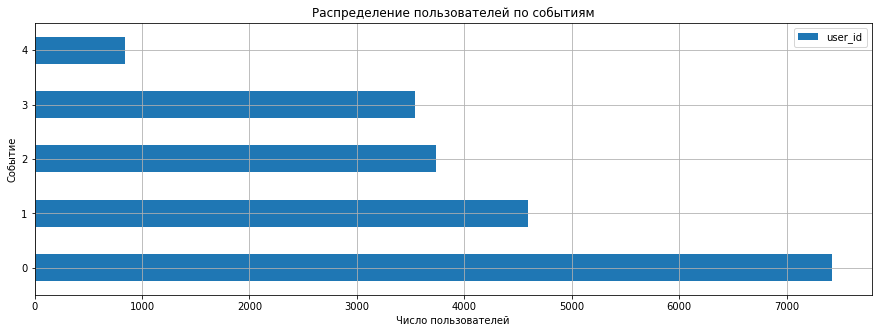

In [36]:
count_user_event.plot(kind='barh', figsize=(15,5), grid=True,)
plt.legend(bbox_to_anchor=(1, 0.8)); # расположение легенды на графике
plt.title('Распределение пользователей по событиям')
plt.legend()
plt.ylabel('Событие')
plt.xlabel('Число пользователей')
plt.show();

In [37]:
# доля пользователей по событиям 
count_user_event['rate_user']=round(count_user_event['user_id']/cl_user_cnt*100, 1)
count_user_event

,event_name,user_id,rate_user
0,MainScreenAppear,7419,98.5
1,OffersScreenAppear,4593,61.0
2,CartScreenAppear,3734,49.6
3,PaymentScreenSuccessful,3539,47.0
4,Tutorial,840,11.1


в 1.5% случаев у пользователей не получается открыть главную страницу;
к странице предложений не перешли в 39% случаев;
в 50% не положили ничего в корзину;
в 53% не делали заказы;
в 11% случаев открывали страницу часто задаваемых вопросов.

In [38]:
# находим user_id пользователей, у которых есть событие "MainScreenAppear"
main=clear_data[clear_data['event_name'] == "MainScreenAppear"]['user_id'].unique()
all_users=clear_data['user_id'].unique()
# определяем пользователей, которые миновали главный экран (т.е., которых нет в main)
not_main = [user_id for user_id in all_users if user_id not in main]

# фильтруем датафрейм для этих пользователей
not_main_users = clear_data[clear_data['user_id'].isin(not_main)]
not_main_users

,event_name,user_id,event_time,exp_id,datetime,date
3223,PaymentScreenSuccessful,5322240575085479425,1564624525,246,2019-08-01 01:55:25,2019-08-01
3224,CartScreenAppear,5322240575085479425,1564624525,246,2019-08-01 01:55:25,2019-08-01
3257,OffersScreenAppear,3187166762535343300,1564624890,247,2019-08-01 02:01:30,2019-08-01
3325,OffersScreenAppear,5322240575085479425,1564625750,246,2019-08-01 02:15:50,2019-08-01
3334,OffersScreenAppear,5322240575085479425,1564625818,246,2019-08-01 02:16:58,2019-08-01
...,...,...,...,...,...,...
242468,PaymentScreenSuccessful,518781617060869985,1565206272,246,2019-08-07 19:31:12,2019-08-07
242469,CartScreenAppear,518781617060869985,1565206273,246,2019-08-07 19:31:13,2019-08-07
242481,PaymentScreenSuccessful,518781617060869985,1565206288,246,2019-08-07 19:31:28,2019-08-07
242483,CartScreenAppear,518781617060869985,1565206289,246,2019-08-07 19:31:29,2019-08-07


In [39]:
# действия одного из пользователей 
not_main_users[not_main_users['user_id']==2890852187923418999].sort_values(by='datetime')

,event_name,user_id,event_time,exp_id,datetime,date
151723,PaymentScreenSuccessful,2890852187923418999,1564999639,246,2019-08-05 10:07:19,2019-08-05
151726,CartScreenAppear,2890852187923418999,1564999640,246,2019-08-05 10:07:20,2019-08-05
151727,OffersScreenAppear,2890852187923418999,1564999642,246,2019-08-05 10:07:22,2019-08-05
193250,OffersScreenAppear,2890852187923418999,1565093848,246,2019-08-06 12:17:28,2019-08-06
193257,CartScreenAppear,2890852187923418999,1565093857,246,2019-08-06 12:17:37,2019-08-06
193258,PaymentScreenSuccessful,2890852187923418999,1565093857,246,2019-08-06 12:17:37,2019-08-06
194277,OffersScreenAppear,2890852187923418999,1565095946,246,2019-08-06 12:52:26,2019-08-06
194310,OffersScreenAppear,2890852187923418999,1565095989,246,2019-08-06 12:53:09,2019-08-06
194317,OffersScreenAppear,2890852187923418999,1565096004,246,2019-08-06 12:53:24,2019-08-06
240852,PaymentScreenSuccessful,2890852187923418999,1565203251,246,2019-08-07 18:40:51,2019-08-07


***Итого:***
- 98.5% пользователей открыли главную страницу приложения;
- 61% открыли страницу с предложениями;
- почти 50% пользователей добавили товары в корзину;
- 47% пользователей оплатили товары
- 11% пользуются страницей часто задаваемых вопросов.

Больше половины пользователей не добавляют ничего в корзину и не делают заказ. Достаточно много пользователей, что не открывают страницу с предложениями. И не у всех открывается главная страница. Следовательно, можно предположить, что в мобильном приложении есть технические неполадки при открытии главной страницы и других. Необходимо выяснить сталкиваются ли пользователи с техническими проблемами страницы корзины/оплаты или же клиенты передумали совершать покупку. 

### Предположить, в каком порядке происходят события. Все ли они выстраиваются в последовательную цепочку? Их не нужно учитывать при расчёте воронки.

Предположительно события происходят так:\
просмотр главной страницы приложения, далее переход на страницу предложений, затем переход на страницу «Корзина» и наконец переход на страницу «Успешная оплата».
Страница часто задаваемых вопросов не входит в цепочку воронки продаж, т.е. пользователи открывают ее по желанию.

### По воронке событий посчитать, какая доля пользователей проходит на следующий шаг воронки (от числа пользователей на предыдущем). То есть для последовательности событий A → B → C посчитать отношение числа пользователей с событием B к количеству пользователей с событием A, а также отношение числа пользователей с событием C к количеству пользователей с событием B.

In [40]:
count_user_event['conversion'] = ((count_user_event['user_id'].pct_change() + 1)*100).round(1)
count_user_event['conversion'].fillna(100, inplace=True)
count_user_event.head(4)

,event_name,user_id,rate_user,conversion
0,MainScreenAppear,7419,98.5,100.0
1,OffersScreenAppear,4593,61.0,61.9
2,CartScreenAppear,3734,49.6,81.3
3,PaymentScreenSuccessful,3539,47.0,94.8


***Итого:***
После просмотра главной страницы на следующий этап воронки просмотра предложений, переходит лишь 62% пользователей. Конверсия перехода на страницу корзины со страницы предложений составляет 81% пользователей. На следующий ключевой шаг воронки успешной оплаты переходит почти 95% пользователей из тех, кто добавил товар в корзину.

### На каком шаге теряете больше всего пользователей?

In [41]:
# цикл для расчета воронки
users = count_user_event.loc[0,'user_id']
for i in count_user_event.index:
    count_user_event.loc[i, 'difference'] = (count_user_event.loc[0,'conversion'] - count_user_event.loc[i,'conversion']).round(1)
    users = count_user_event.loc[i,'user_id']
display(count_user_event.head(4))

,event_name,user_id,rate_user,conversion,difference
0,MainScreenAppear,7419,98.5,100.0,0.0
1,OffersScreenAppear,4593,61.0,61.9,38.1
2,CartScreenAppear,3734,49.6,81.3,18.7
3,PaymentScreenSuccessful,3539,47.0,94.8,5.2


Больше всего потерянных пользователей на шаге перехода с главной страницы на страницу предложений - 38%.

***Итого:***
- 38% пользователей не переходят с главной страницы на страницу предложений;
- почти 19% пользователей не добавляют товары в корзину после просмотра предложений;
- 5% пользователей не оплачивают товар после добавления товара в корзину.

Вывод, что что-то не так с главной страницей, уж слишком маленькая конверсия перехода на страницу предложений. Либо технические проблемы, либо не столь интересный контент, либо не нашли на главной странице интересующий блок, приводящий к странице предложений. Так же есть 5% пользователей, которые не оплатили свою корзину. Возможно, пользователям не понятны по условиям доставки, так как есть процент пользователей, которые обращались к странице часто задаваемым вопросам. 

### Какая доля пользователей доходит от первого события до оплаты?

In [42]:
users = count_user_event.loc[0,'user_id']
total_users = users

for i in count_user_event.index:
# расчет конверсии для последовательности событий A → B,  A  → C
    count_user_event.loc[i,'total_conversion'] = (count_user_event.loc[i,'user_id'] / total_users * 100).round(1)
    
display(count_user_event.head(4))

,event_name,user_id,rate_user,conversion,difference,total_conversion
0,MainScreenAppear,7419,98.5,100.0,0.0,100.0
1,OffersScreenAppear,4593,61.0,61.9,38.1,61.9
2,CartScreenAppear,3734,49.6,81.3,18.7,50.3
3,PaymentScreenSuccessful,3539,47.0,94.8,5.2,47.7


***Итого:***
От просмотра главной страницы до успешной оплаты доходят лишь 47% пользователей.

***Вывод:***
- 98.5% пользователей открыли главную страницу приложения;
- 61% открыли страницу с предложениями;
- почти 50% пользователей добавили товары в корзину;
- 47% пользователей оплатили товары;
- 11% пользуются страницей часто задаваемых вопросов.

Больше половины пользователей не добавляют ничего в корзину и не делают заказ. Достаточно много пользователей, что не открывают страницу с предложениями. И не у всех открывается главная страница. Следовательно, можно предположить, что в мобильном приложении есть технические неполадки при открытии главной страницы.

Хронология событий:
просмотр главной страницы приложения, далее переход на страницу предложений, затем переход на страницу «Корзина» и наконец переход на страницу «Успешная оплата». Страница часто задаваемых вопросов не входит в цепочку воронки продаж, т.е. пользователи открывают ее по желанию.

После просмотра главной страницы на следующий этап воронки просмотра предложений, переходит лишь 62% пользователей. Конверсия перехода на страницу корзины со страницы предложений составляет 81% пользователей. На следующий ключевой шаг воронки успешной оплаты переходит почти 95% пользователей из тех, кто добавил товар в корзину.

- 1.5% пользователей не могут открыть главную страницу;
- 38% пользователей не переходят с главной страницы на страницу предложений;
- почти 19% пользователей не добавляют товары в корзину после просмотра предложений;
- 5% пользователей не оплачивают товар после добавления товара в корзину.

Можно сделать вывод, что что-то не так с главной страницей, уж слишком маленькая конверсия перехода на страницу предложений. Либо технические проблемы, либо не столь интересный контент, либо не нашли на главной странице интересующий блок, приводящий к странице предложений.
Чтобы увеличить конверсию перехода на страницу корзины, возможно стоит сообщать о акциях в виде выгодных предложений на странице предложений и выяснить потребности пользователя по поиску. \
Так же есть 5% пользователей, которые не оплатили свою корзину. Возможно, нужно замотивировать клиента к покупке в моменте, добавляя подарки или предоставляя бесплатную доставку на странице корзины, или же, возможно, пользователям не понятны по условиям доставки, так как есть процент пользователей, которые обращались к странице часто задаваемым вопросам. 

## Изучить результаты эксперимента

### Сколько пользователей в каждой экспериментальной группе?

In [43]:
clear_count_user

,exp_id,user_id
0,246,2484
1,247,2513
2,248,2537


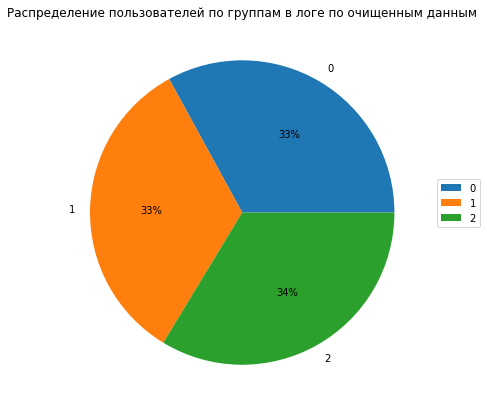

In [44]:
clear_count_user.plot(kind='pie', y='user_id', autopct='%1.0f%%', figsize=(7,7), label='')
plt.legend(bbox_to_anchor=(1, 0.6)); # расположение легенды на графике
plt.title('Распределение пользователей по группам в логе по очищенным данным');

***Итого:***

В 248 группе: 2537 человек \
В 247 группе: 2513 человек \
В 246 группе: 2484 человек

Две контрольные группы со старыми шрифтами 246 и 247 все также одинаковы в процентном соотношении - по 33%. Экспериментальная группа, аналогично сырым данным, составляет 34% пользователей.

### Есть 2 контрольные группы для А/А-эксперимента, чтобы проверить корректность всех механизмов и расчётов. Проверить, находят ли статистические критерии разницу между выборками 246 и 247. Выбрать самое популярное событие. Посчитать число пользователей, совершивших это событие в каждой из контрольных групп. Посчитать долю пользователей, совершивших это событие. Проверить, будет ли отличие между группами статистически достоверным. Проделать то же самое для всех других событий (удобно обернуть проверку в отдельную функцию). Можно ли сказать, что разбиение на группы работает корректно?

Сформулируем гипотезы.\
Нулевая: различий между выборками нет.\
Альтернативная: различия между выборками есть.

In [45]:
# кол-во уникальных пользователей по группам и событиям
users_all=clear_data.pivot_table(index='exp_id', columns='event_name', values='user_id', aggfunc='nunique').reset_index()
users_all['Total'] = [clear_count_user['user_id'][0], clear_count_user['user_id'][1], clear_count_user['user_id'][2]]
users_all

event_name,exp_id,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial,Total
0,246,1266,2450,1542,1200,278,2484
1,247,1238,2476,1520,1158,283,2513
2,248,1230,2493,1531,1181,279,2537


Самое популярное событие - это MainScreenAppear	- просмотр главной страницы. 

In [46]:
gr=clear_data.loc[clear_data['exp_id'] == 246]# данные из 246 группы
gr_one=gr.groupby('event_name')['user_id'].nunique()
grr=clear_data.loc[clear_data['exp_id'] == 247]# данные из 247 группы
gr_two=grr.groupby('event_name')['user_id'].nunique()

In [47]:
alpha=0.05
results = st.ttest_ind(gr_one, gr_two)

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')  

p-value: 0.9809573661651472
Не получилось отвергнуть нулевую гипотезу


Слишком большая вероятность, чтобы делать вывод о значимом различии между контрольными группами. Считаем, что различия между группами 246 и 247 отсутствуют.

In [48]:
# Напишем функцию для проверки гипотез
def stat_test (success, trials, alpha):
    # доля пользователей, совершивших событие в первой группе:
    p1 = success[0] / trials[0]
    # доля пользователей, совершивших событие во второй группе:
    p2 = success[1] / trials[1]
    # доля пользователей, совершивших событие в комбинированном датасете:
    p_combined = (success[0] + success[1]) / (trials[0] + trials[1])
    # разница долей в датасетах
    difference = p1 - p2
 
    z_value = difference / mth.sqrt(p_combined *(1-p_combined) * (1/trials[0] + 1/trials[1]))
    
    distr = st.norm(0, 1) 
    
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    print('p-значение: ', p_value)
    
    if (p_value < alpha):
        print("Отвергаем нулевую гипотезу: следовательно, между выборками есть значимая разница")
        print('')
    else:
        print("Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными")
        print('')

In [49]:
# Напишем функцию, которая на вход получает порядковый номер группы в таблице и параметр альфа, и возвращает результаты проверки гипотез
def stat_value (group_246, group_247, alpha):
    alpha_test = alpha
    count_CartScreenAppear = ([users_all['CartScreenAppear'][group_246], users_all['CartScreenAppear'][group_247]]) 
    count_MainScreenAppear = ([users_all['MainScreenAppear'][group_246], users_all['MainScreenAppear'][group_247]])
    count_OffersScreenAppear = ([users_all['OffersScreenAppear'][group_246], users_all['OffersScreenAppear'][group_247]])
    count_PaymentScreenSuccessful = ([users_all['PaymentScreenSuccessful'][group_246], \
                                      users_all['PaymentScreenSuccessful'][group_247]])
    count_Tutorial = ([users_all['Tutorial'][group_246], users_all['Tutorial'][group_247]]) 
    total_users = ([users_all['Total'][group_246], users_all['Total'][group_247]])
    
    print('Результаты теста по событию CartScreenAppear для контрольных групп')
    stat_test(count_CartScreenAppear, total_users, alpha_test)
              
    print('Результаты теста по событию MainScreenAppear для контрольных групп')
    stat_test(count_MainScreenAppear, total_users, alpha_test)
    
    print('Результаты теста по событию OffersScreenAppear для контрольных групп')
    stat_test(count_OffersScreenAppear, total_users, alpha_test)
        
    print('Результаты теста по событию PaymentScreenSuccessful для контрольных групп')
    stat_test(count_PaymentScreenSuccessful, total_users, alpha_test)
    
    print('Результаты теста по событию Tutorial для контрольных групп')
    stat_test(count_Tutorial, total_users, alpha_test)

In [50]:
# проверка контрольных групп 246 и 247
stat_value (0, 1, 0.05)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.22883372237997213
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.7570597232046099
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.2480954578522181
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.11456679313141849
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.9376996189257114
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



***Итого:***
Для контрольных групп 246 и 247 проводилось 5 тестов на основании попарного сравнения событий. Самое популярное событие - это MainScreenAppear	- просмотр главной страницы. Результаты А/А-теста показали, что между выборками 246 и 247 нет статистически значимых различий и различия в количестве пользователей по событиям между группами не значимы. Следовательно, разбиение на группы корректно и А/В-тестирования будут проведены верно. 

### Аналогично поступить с группой с изменённым шрифтом. Сравнить результаты с каждой из контрольных групп в отдельности по каждому событию. Сравнить результаты с объединённой контрольной группой. Какие выводы из эксперимента можно сделать?

In [51]:
# проверка контрольной 246 и экспериментальной 248 групп
stat_value (0, 2, 0.05)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.07842923237520116
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.2949721933554552
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.20836205402738917
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.2122553275697796
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.8264294010087645
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



In [52]:
# проверка контрольной 247 и экспериментальной 248 групп
stat_value (1, 2, 0.05)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.5786197879539783
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.4587053616621515
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.9197817830592261
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.7373415053803964
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.765323922474501
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



In [53]:
# объединяем 2 контрольные группы 
users_new = users_all.loc[0]+users_all.loc[1]
users_new

event_name
exp_id                      493
CartScreenAppear           2504
MainScreenAppear           4926
OffersScreenAppear         3062
PaymentScreenSuccessful    2358
Tutorial                    561
Total                      4997
dtype: int64

In [54]:
# добовляем в таблицу данные по объединённой контрольной группе
users_all = users_all.append(users_new, ignore_index=True)
users_all

event_name,exp_id,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial,Total
0,246,1266,2450,1542,1200,278,2484
1,247,1238,2476,1520,1158,283,2513
2,248,1230,2493,1531,1181,279,2537
3,493,2504,4926,3062,2358,561,4997


In [55]:
# проверка экспериментальной 248 группы с объединённой контрольной группой
stat_value (3, 2, 0.05)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.18175875284404386
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.29424526837179577
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.43425549655188256
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.6004294282308704
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.764862472531507
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



***Итого:***
Результаты А/В-тестов показали, что нет статистически значимого различия по числу пользователей в событиях между группами 246-248, 247-248 и 248 с объединенной контрольной группой(493). Следовательно, изменение шрифта не повлияло на поведение пользователей.

### Какой уровень значимости вы выбрали при проверке статистических гипотез выше? Посчитать, сколько проверок статистических гипотез вы сделали. При уровне значимости 0.1 в 10% случаев можно ошибочно отклонить нулевую гипотезу при условии, что она верна. Какой уровень значимости стоит применить? Если вы хотите изменить его, проделайте предыдущие пункты и проверьте свои выводы.

Для проверки гипотез был выбран стандартный уровень значимости - 0.05. И при таком показатели α статистически значимых различий в количестве пользователей между группами обнаружено не было. 

При множественном тестировании и достаточно большом α возникает риск ошибочно отклонить нулевую гипотезу при условии, что она верна, из-за накопительной ошибки.

In [56]:
# проверка контрольных групп 246 и 247
stat_value (0, 1, 0.1)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.22883372237997213
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.7570597232046099
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.2480954578522181
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.11456679313141849
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.9376996189257114
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



In [57]:
# проверка контрольной 246 и экспериментальной 248 групп
stat_value (0, 2, 0.1)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.07842923237520116
Отвергаем нулевую гипотезу: следовательно, между выборками есть значимая разница

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.2949721933554552
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.20836205402738917
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.2122553275697796
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.8264294010087645
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



Вот она ошибка первого рода при множественном тестировании и достаточно большом α.

In [58]:
# проверка контрольной 247 и экспериментальной 248 групп
stat_value (1, 2, 0.1)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.5786197879539783
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.4587053616621515
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.9197817830592261
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.7373415053803964
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.765323922474501
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



In [59]:
# проверка экспериментальной 248 группы с объединённой контрольной группой
stat_value (3, 2, 0.1)

Результаты теста по событию CartScreenAppear для контрольных групп
p-значение:  0.18175875284404386
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию MainScreenAppear для контрольных групп
p-значение:  0.29424526837179577
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию OffersScreenAppear для контрольных групп
p-значение:  0.43425549655188256
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию PaymentScreenSuccessful для контрольных групп
p-значение:  0.6004294282308704
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными

Результаты теста по событию Tutorial для контрольных групп
p-значение:  0.764862472531507
Не получилось отвергнуть нулевую гипотезу, нет оснований считать выборки разными



Между контрольной 246 и экспериментальной 248 группами по событию CartScreenAppear в количестве пользователей обнаружены различия. Но между 246 и 247 нет различий, так же, как и между 247 и 248. Даже между 248 и объединённой контрольной группой нет статистически значимых различий. Следовательно, при уровне значимости 0.1 ошибочно обнаруживаем ошибки там, где их в реальности нет, т.е. появляется ошибка первого рода. Тогда необходимо понизить уровень значимости. \
Каждая группа состоит из 5 событий, которые нужно сравнить попарно. Это значит, что на одном наборе данных нужно провести 5 тестов - это множественная проверка гипотез. Таких групп 4, следовательно, проведено 20 тестов. При выполнении множественного тестирования возникает серьёзная проблема — быстрый рост вероятности допустить ошибку первого рода, то есть возникает накопительная ошибка. Такая групповая вероятность ошибки первого рода зависит от уровень статистической значимости (α) от числа проводимых тестов. Чтобы снизить накопительную ошибку, необходимо скорректировать α. Коррекция уровня значимости по методу Холма позволяет одновременно и понизить накопительную ошибку, и повысить мощность теста.


In [60]:
# коррекция уровня значимости по методу Холма
m, alpha = 20, 0.1 # число тестов и уровень значимости
result = []
for i in range(m): # получаем номер текущего теста и считаем коррекцию 
    result += [alpha / (m - i)]
print(result) 

[0.005, 0.005263157894736842, 0.005555555555555556, 0.0058823529411764705, 0.00625, 0.006666666666666667, 0.0071428571428571435, 0.007692307692307693, 0.008333333333333333, 0.009090909090909092, 0.01, 0.011111111111111112, 0.0125, 0.014285714285714287, 0.016666666666666666, 0.02, 0.025, 0.03333333333333333, 0.05, 0.1]


Не имеет смысла проводить тест с уровнем значимости 0.005, так как при очень малом α возникает риск совершить ошибку второго рода - неверно принять нулевую гипотезу. 

***Итого:***
Была проведена множественная проверка гипотез - каждую группу из 5 событий попарно сравнили, т.е. проведено 20 тестов. При выполнении множественного тестирования и достаточно большом уровне значимости возникает серьёзная проблема — быстрый рост вероятности допустить ошибку первого рода, то есть возникает накопительная ошибка. Как раз при α = 0.1 наблюдается ошибка первого рода. Чтобы снизить накопительную ошибку была проведена коррекция α по методу Холма. Но и при слишком малом α возникает риск совершить ошибку второго рода - неверно принять нулевую гипотезу. Поэтому для проведения A/A/B-теста взяли α = 0.05.\
При таком показатели α статистически значимых различий в количестве пользователей по событиям между группами обнаружено не было.  Следовательно, вывод - изменение шрифта не повлияло на поведение пользователей. 

***Общий вывод:***

В целях повышения качества взаимодействия пользователей с приложением было изучено поведение пользователей, проанализирована воронка продаж и исследуемы результаты A/A/B-эксперимента. Датасет содержит информацию с 25 июля 2019 по 7 августа 2019 года о двух контрольных группах и одной экспериментальной с уникальными id пользователя, названием события и временем события.

Событий в лого 5 видов:
- MainScreenAppear - Просмотр главной страницы приложения; 
- OffersScreenAppear - Перешёл на страницу предложений; 
- CartScreenAppear - Перешёл на страницу «Корзина» 
- PaymentScreenSuccessful - Перешёл на страницу «Успешная оплата»;
- Tutorial - Перешёл на страницу часто задаваемых вопросов.

На этапе предобработки данных дубликаты были удалены, изменили названия столбов и привели их к правилам стиля, пропусков обнаружено не было. Добавлен столбец даты и времени, а также отдельный столбец дат. 

Исследуя датасет были обнаружены выбросы - в первые 7 дней число событий в группах аномально низкие - это дни с неполными данными. Возможно, это связано со стартом работы приложения. Следовательно, достаточное количество записей в логах для проведения событийного анализа начинается с 1 августа 2019.\
Процент очищенных данных составил 1%.

По сырым данным:
- период предоставлен за 13 days 16:31:41 с 25 июля 2019 по 7 августа 2019;
- число пользователей в логе 7551;
- распределение пользователей по группам практически одинаково: две контрольные группы со старыми шрифтами 246 и 247 по 33% пользователей, а экспериментальная группа составляет 34%;
- количество событий 243713;
- в среднем на пользователя приходится 32 события.

Чаще всего обращаются к главной странице приложения - 49% обращений. Важнейшее событие для бизнеса - это переход на страницу успешной оплаты, и тут всего 14% обращений к странице. Страницу часто задаваемых вопросов вызывают крайне редко - 0.4%. Практически одинаково осуществляется вывод на экран страницы корзины и страницы предложений 17.5-19%, лишь небольшая разница между ними в 1.5% говорит о том, что данные пользователи не добавляют ничего в корзину.

По очищенным данным:
- актуальный период за 6 days 21:07:49 с 1 августа 2019 по 7 августа 2019;
- число пользователей в логе 7534;
- распределение пользователей по группам аналогично сырым данным - по 33% и 34%;
- количество событий 240887;
- в среднем на пользователя приходится также 32 события. 

После очистки данных частота обращений событиям не изменилась.

Анализируя поведение пользователей, было установлено следующие:
- 98.5% пользователей открыли главную страницу приложения;
- 61% открыли страницу с предложениями;
- 50% пользователей добавили товары в корзину;
- 47% пользователей оплатили товары;
- 11% пользуются страницей часто задаваемых вопросов.
- Хронология событий:
просмотр главной страницы приложения, далее переход на страницу предложений, затем переход на страницу «Корзина» и наконец переход на страницу «Успешная оплата». Страница часто задаваемых вопросов не входит в цепочку воронки продаж, т.е. пользователи открывают ее по желанию. 
- 38% пользователей не переходят с главной страницы на страницу предложений;
- 19% пользователей не добавляют товары в корзину после просмотра предложений;
- 5% пользователей не оплачивают товар после добавления товара в корзину.

Не у всех открывается главная страница, возможно есть технические неполадки в приложении, но действия таких пользователей показали, что это повторные пользователи, что переходят после оплаты сразу к предложениям. Достаточно много пользователей, что не открывают страницу с предложениями. Больше половины всех пользователей не добавляют ничего в корзину и не делают заказ. 

Можно сделать вывод, что что-то не так с главной страницей, уж слишком маленькая конверсия перехода на страницу предложений. Либо технические проблемы, либо не столь интересный контент, либо не нашли на главной странице интересующий блок, приводящий к странице предложений.
Чтобы увеличить конверсию перехода на страницу корзины, возможно стоит сообщать о акциях в виде выгодных предложений на странице предложений и выяснить потребности пользователя по поиску. \
Так же есть 5% пользователей, которые не оплатили свою корзину. Возможно, нужно замотивировать клиента к покупке в моменте, добавляя подарки или предоставляя бесплатную доставку на странице корзины, или же, возможно, пользователям не понятны по условиям доставки, так как есть процент пользователей, которые обращались к странице часто задаваемым вопросам. 

По результатам анализа и тестов: 
- самое популярное событие - это MainScreenAppear - просмотр главной страницы.
- статистический тест показал, что различия между группами 246 и 247 отсутствуют;
- по результатам А/А-теста нет статистически значимых различий по числу пользователей в событиях. Следовательно, разбиение на группы корректно и А/В-тестирования будут проведены верно;
- результаты А/В-тестов показали, что нет статистически значимого различия по числу пользователей в событиях между группами 246-248, 247-248 и 248 с объединенной контрольной группой(493). Следовательно, изменение шрифта не повлияло на поведение пользователей.